# Hedging a Book of (EM) Callable Bonds

A bond desk can hold bonds with embedded call options, mostly Bermudan style in practice. For a AAA issuer, hedging is simple: enter the offsetting position. Below A+ it is not, because the call decision now depends on two stochastic factors: interest rates and the issuer's credit spread.

**The setup.** A AAA rated institution funds itself at SOFR flat and buys emerging market (EM) callable bonds. The credit risk is deliberate, it is the mandate and how the desk earns its spread. What it wants to strip out is the interest rate risk, using vanilla interest rate swaps.

The intuition is that if an option's value depends on two random factors, an instrument tied to only one of them cannot fully hedge it. That sounds like a dead end here. It is not. The fix is to immunize the book's rate risk bucket by bucket with a strip of vanilla swaps, then rebalance as the hedge decays.

> **The question:** can we strip the interest rate risk out of a book of callable EM bonds using vanilla swaps? How do we size the trade, how much risk does it remove, and how fast does it stop working?

The pricing engine is `fixed_income.py`, validated against published examples in Notebook 1.

**Contents**
1. The position
2. Where the risk sits on the curve
3. Three hedges for one bond
4. The book
5. Value at risk
6. Hedge decay and the cost of rebalancing
7. Limitations

Appendix: the maturity sandwich and effective maturity


---
## 1. The position

The bond is a five year, non call two (5NC2): callable each year from year 2, 10% coupon, 425bp credit spread, $10M face, 15% assumed rate volatility.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from fixed_income import (load_market_data, bootstrap_curve, get_df, bump_curve,
                          price_swap, swap_npv, swap_krd_vector,
                          bond_pricer_lattice, issuer_par_curve)

df, _ = bootstrap_curve(load_market_data("market_data.csv"))

First, why credit matters here. Below is the same 5NC2 bond from three issuers. Only the spread changes.


In [6]:
issuers = [
    {"name": "AAA issuer", "spread": 0.0050},
    {"name": "IG issuer",  "spread": 0.0150},
    {"name": "EM issuer",  "spread": 0.0425},
]

coupon, tenor, vol, first_call = 0.10, 5, 0.15, 2

print(f"5NC2 Callable Bond  |  Coupon {coupon*100:.0f}%  |  Vol {vol*100:.0f}%")
print("-" * 70)
print(f"  {'Issuer':<12}  {'Spread':>7}  {'Free':>9}  {'Callable':>9}  {'Option':>8}")
print("-" * 70)

for issuer in issuers:
    curve = issuer_par_curve(df, issuer["spread"])
    p_free = bond_pricer_lattice(coupon, tenor, curve, vol)
    p_call=bond_pricer_lattice(coupon, tenor, curve, vol,
                                 call=True, call_price=100,
                                 first_call_year=first_call)
    print(f"  {issuer['name']:<12}  {issuer['spread']*10000:>4.0f}bp  {p_free:>9.3f}  {p_call:>9.3f}  {p_free - p_call:>8.3f}")
print("-" * 70)

5NC2 Callable Bond  |  Coupon 10%  |  Vol 15%
----------------------------------------------------------------------
  Issuer         Spread       Free   Callable    Option
----------------------------------------------------------------------
  AAA issuer      50bp    123.748    110.819    12.929
  IG issuer      150bp    118.822    108.811    10.011
  EM issuer      425bp    106.555    102.756     3.799
----------------------------------------------------------------------


The option is worth most to the AAA issuer and least to the EM one. Lower discount rates give a higher bond price, so the call is further in the money and more likely to be exercised.

So the credit spread sets the value of the option, which sets the expected life of the bond, which sets its interest rate risk. That chain is what makes this hard to hedge.

Our position from here on is the EM bond.


In [9]:
# the position
EM_SPREAD, COUPON, TENOR, VOL = 0.0425, 0.10, 5, 0.15
FIRST_CALL, CALL_PRICE, NOTIONAL = 2, 100, 10_000_000
bump = 0.0001

em_curve = issuer_par_curve(df, EM_SPREAD)

def price_callable(par_rates):
    """Price the 5NC2 callable on a given issuer par curve."""
    return bond_pricer_lattice(COUPON, TENOR, par_rates, VOL,
                               call=True, call_price=CALL_PRICE,
                               first_call_year=FIRST_CALL)

def price_bullet(par_rates):
    """Price the same bond stripped of its call, for comparison."""
    return bond_pricer_lattice(COUPON, TENOR, par_rates, VOL)

def shift_curve(par_rates, shift):
    """Parallel shift of every par rate on a curve."""
    shifted = []
    for r in par_rates:
        shifted.append(r + shift)
    return shifted

# symmetric 1bp bump
p0_call = price_callable(em_curve)
p_up = price_callable(shift_curve(em_curve, +bump))
p_dn = price_callable(shift_curve(em_curve, -bump))
oa_dv01 = (p_dn - p_up) / 2 * (NOTIONAL / 100)

p0_free = price_bullet(em_curve)
pf_up = price_bullet(shift_curve(em_curve, +bump))
pf_dn = price_bullet(shift_curve(em_curve, -bump))
free_dv01 = (pf_dn - pf_up) / 2 * (NOTIONAL / 100)

eff_dur_call = (p_dn - p_up) / (2 * p0_call * bump)
eff_dur_free = (pf_dn - pf_up) / (2 * p0_free * bump)

print("-" * 60)
print(f"  OA-DV01 Analysis  |  5NC2  |  Coupon 10%  |  $10M face")
print("-" * 60)
print(f"  Callable price       : {p0_call:.3f}")
print(f"  Price, rates +1bp    : {p_up:.3f}")
print(f"  Price, rates -1bp    : {p_dn:.3f}")
print("-" * 60)
print(f"  OA-DV01  (callable)  : ${oa_dv01:,.0f}     eff dur {eff_dur_call:.2f}Y")
print(f"  DV01 (option-free)   : ${free_dv01:,.0f}     eff dur {eff_dur_free:.2f}Y")
print(f"  Callable / free      : {oa_dv01 / free_dv01 * 100:.1f}%")
print("-" * 60)

# checkpoint: the call must REDUCE rate sensitivity
assert oa_dv01 < free_dv01, "callable DV01 should be below vanilla DV01"
print("OA-DV01 < vanilla DV01")

------------------------------------------------------------
  OA-DV01 Analysis  |  5NC2  |  Coupon 10%  |  $10M face
------------------------------------------------------------
  Callable price       : 102.756
  Price, rates +1bp    : 102.731
  Price, rates -1bp    : 102.781
------------------------------------------------------------
  OA-DV01  (callable)  : $2,452     eff dur 2.39Y
  DV01 (option-free)   : $4,145     eff dur 3.89Y
  Callable / free      : 59.2%
------------------------------------------------------------
OA-DV01 < vanilla DV01


The call removes about 40% of the bond's rate sensitivity. We own the bond and are short the option, and the option gains value as rates fall.

The ratio is not fixed. It depends on where rates are, because the chance of being called does.


In [12]:
scenarios = [
    {"name": "rates down 300bp", "shift": -0.03},
    {"name": "base case",        "shift":  0.00},
    {"name": "rates up 300bp",   "shift": +0.03},
]

print("-" * 74)
print(f"  {'Scenario':<18}  {'Bullet dur':>10}  {'Callable dur':>12}  {'Callable px':>12}")
print("-" * 74)

for s in scenarios:
    base = shift_curve(em_curve, s["shift"])

    pc = price_callable(base)
    dc = (price_callable(shift_curve(base, -bump)) - price_callable(shift_curve(base, +bump))) / (2 * pc * bump)

    pf = price_bullet(base)
    dfree = (price_bullet(shift_curve(base, -bump)) - price_bullet(shift_curve(base, +bump))) / (2 * pf * bump)

    print(f"  {s['name']:<18}  {dfree:>9.2f}Y  {dc:>11.2f}Y  {pc:>12.3f}")
print("-" * 74)

--------------------------------------------------------------------------
  Scenario            Bullet dur  Callable dur   Callable px
--------------------------------------------------------------------------
  rates down 300bp         4.05Y         1.82Y       109.308
  base case                3.89Y         2.39Y       102.756
  rates up 300bp           3.74Y         3.27Y        94.173
--------------------------------------------------------------------------


Volatility is an assumed input. Higher volatility makes the issuer's option more valuable, so the bond is worth less, even though no cash flow has changed.


In [68]:
# how much does the vol assumption matter, in points?
print(f"  {'vol':>5}  {'callable px':>12}  {'option value':>13}")
print("  " + "-" * 34)
for v in [0.05, 0.10, 0.15, 0.20, 0.25]:
    pc=bond_pricer_lattice(COUPON, TENOR, em_curve, vol=v,
                             call=True, call_price=CALL_PRICE,
                             first_call_year=FIRST_CALL)
    pf = bond_pricer_lattice(COUPON, TENOR, em_curve, vol=v)
    print(f"  {v*100:>4.0f}%  {pc:>12.3f}  {pf - pc:>13.3f}")
print("  " + "-" * 34)
print("  A 5-point change moves the bond price by more than half a point,making volatility calibration a material model limitation.")

    vol   callable px   option value
  ----------------------------------
     5%       103.571          2.985
    10%       103.261          3.294
    15%       102.756          3.799
    20%       102.233          4.323
    25%       101.707          4.848
  ----------------------------------
  A 5-point change moves the bond price by more than half a point,making volatility calibration a material model limitation.


---
## 2. Where the risk sits on the curve

A single parallel DV01 hides the shape of the exposure. The key rate duration (KRD) vector bumps one curve pillar at a time and reprices, turning one number into five.


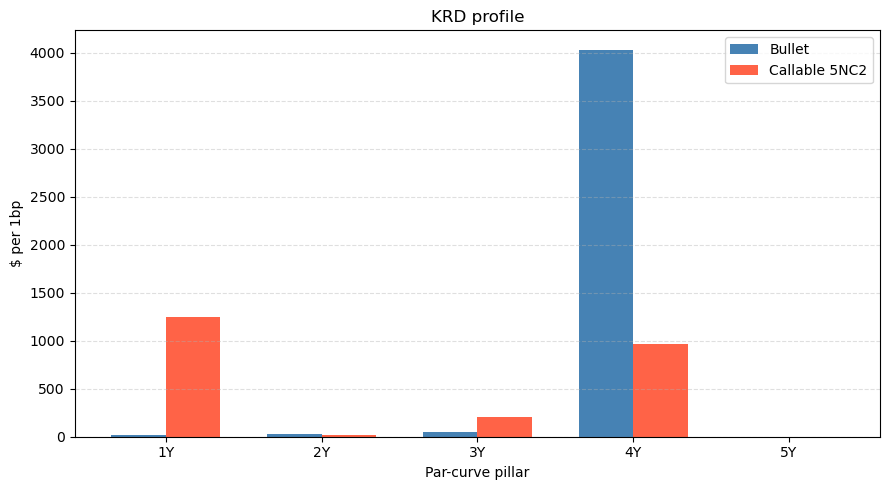

In [18]:
def krd_vector_lattice(pricer, par_rates, notional):
    """Key rate durations: bump each pillar by 1bp in turn and fully reprice."""
    krds = []
    for pillar in range(1, TENOR + 1):
        up = list(par_rates)
        dn = list(par_rates)
        up[pillar] += bump
        dn[pillar] -= bump

        krd = (pricer(dn) - pricer(up)) / 2 * (notional / 100)
        krds.append(krd)

    return krds

krd_bond_call = krd_vector_lattice(price_callable, em_curve, NOTIONAL)
krd_bond_free = krd_vector_lattice(price_bullet, em_curve, NOTIONAL)

pillars = [1, 2, 3, 4, 5]
x = np.arange(len(pillars))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - width / 2, krd_bond_free, width,
       color="steelblue", label="Bullet")
ax.bar(x + width / 2, krd_bond_call, width,
       color="tomato", label="Callable 5NC2")

ax.set_title("KRD profile")
ax.set_xlabel("Par-curve pillar")
ax.set_ylabel("$ per 1bp")
ax.set_xticks(x)
ax.set_xticklabels([f"{p}Y" for p in pillars])
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

The bullet has nearly all its risk at the maturity pillar, where the principal is. For the callable, most of its risk sits at the short end, because the market expects it to be retired early.

---
## 3. Three hedges

- Unhedged, as a baseline.
- Naive: pay fixed on a 2Y swap for the full face, on the view that the bond is called at year 2.
- KRD strip: one pay fixed swap per pillar, each sized so its own bucket offsets the bond's.

The strip is solved longest pillar first. A 4Y swap has coupons at years 1, 2 and 3, so it also moves those buckets, which means the swaps cannot be sized independently. A 3Y swap has no sensitivity at 4Y, so in longest to shortest order the system is triangular and solves by back substitution.


In [21]:
def swap_npv(df_curve, tenor, fixed_rate, notional):
    """NPV of a pay-fixed swap under any discount curve, positive when rates have risen."""
    annuity = 0.0
    for cy in range(1, tenor + 1):
        annuity += get_df(cy, df_curve)
    float_leg = 1.0 - get_df(tenor, df_curve)
    return (float_leg - fixed_rate * annuity) * notional

def swap_krd_vector(df, tenor, fixed_rate, notional):
    """Key rate durations of a pay-fixed swap, one pillar at a time."""
    base = swap_npv(df, tenor, fixed_rate, notional)
    krds = []
    for pillar in [1, 2, 3, 4, 5]:
        krds.append(swap_npv(bump_curve(df, pillar), tenor, fixed_rate, notional) - base)
    return krds

# hedge 1: naive, pay fixed 2Y on the full face
s2 = price_swap(df, tenor=2, notional=NOTIONAL, verbose=False)
hedge_naive = [(2, s2["par_rate"], NOTIONAL)]

# hedge 2: KRD strip, offset each bucket, longest pillar first
hedge_strip = []
residual = list(krd_bond_call)

for pillar in [5, 4, 3, 2, 1]:
    if abs(residual[pillar - 1]) < 50:        # ignore noise-level buckets
        continue
    sp = price_swap(df, tenor=pillar, notional=1_000_000, verbose=False)
    unit_krd = swap_krd_vector(df, pillar, sp["par_rate"], 1_000_000)
    size = residual[pillar - 1] / unit_krd[pillar - 1] * 1_000_000
    hedge_strip.append((pillar, sp["par_rate"], size))
    # subtract this swap's KRD (all buckets) from what is left to hedge
    for i in range(5):
        residual[i] -= unit_krd[i] * size / 1_000_000

def hedge_krd(hedge):
    """Total KRD vector of a hedge, summed across all its swaps."""
    total = [0.0] * 5
    for tenor_h, k, size in hedge:
        v = swap_krd_vector(df, tenor_h, k, size)
        for i in range(5):
            total[i] += v[i]
    return total

krd_h1 = hedge_krd(hedge_naive)
krd_h2 = hedge_krd(hedge_strip)

resid_naive = [krd_bond_call[i] - krd_h1[i] for i in range(5)]
resid_strip = [krd_bond_call[i] - krd_h2[i] for i in range(5)]

print("Hedge 1, naive:")
print(f"   2Y pay-fixed @ {s2['par_rate']*100:.4f}%   notional ${NOTIONAL:,.0f}   swap DV01 ${sum(krd_h1):,.0f}")
print(f"   net DV01 vs bond: ${sum(krd_bond_call) - sum(krd_h1):,.0f}")

print("\nHedge 2, KRD immunization strip:")
for tenor_h, k, size in sorted(hedge_strip):
    print(f"   {tenor_h}Y pay-fixed @ {k*100:.4f}%   notional ${size:,.0f}")
print(f"   strip DV01 ${sum(krd_h2):,.0f}   net DV01 vs bond: ${sum(krd_bond_call) - sum(krd_h2):,.0f}")

print("\nResidual KRD by pillar ($/bp):")
print(f"  {'Pillar':>7}  {'Bond':>9}  {'Unhedged':>9}  {'Naive':>9}  {'Strip':>9}")
for i, p in enumerate(pillars):
    print(f"  {str(p)+'Y':>7}  ${krd_bond_call[i]:>8,.0f}  ${krd_bond_call[i]:>8,.0f}  ${resid_naive[i]:>8,.0f}  ${resid_strip[i]:>8,.0f}")

Hedge 1, naive:
   2Y pay-fixed @ 3.8500%   notional $10,000,000   swap DV01 $1,963
   net DV01 vs bond: $474

Hedge 2, KRD immunization strip:
   1Y pay-fixed @ 3.7500%   notional $12,336,956
   3Y pay-fixed @ 3.9800%   notional $651,544
   4Y pay-fixed @ 4.1000%   notional $2,720,255
   strip DV01 $2,447   net DV01 vs bond: $-10

Residual KRD by pillar ($/bp):
   Pillar       Bond   Unhedged      Naive      Strip
       1Y  $   1,247  $   1,247  $   1,210  $      -0
       2Y  $      15  $      15  $  -1,910  $     -10
       3Y  $     210  $     210  $     210  $       0
       4Y  $     964  $     964  $     964  $       0
       5Y  $       0  $       0  $       0  $       0


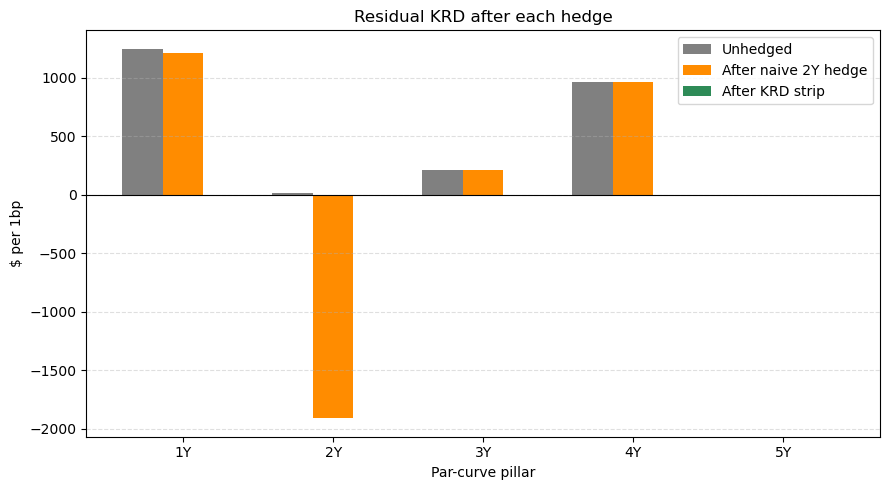

In [25]:
# residual risk, visually
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(5)
width = 0.27
ax.bar(x - width, krd_bond_call, width, color="gray",      label="Unhedged")
ax.bar(x,         resid_naive,   width, color="darkorange", label="After naive 2Y hedge")
ax.bar(x + width, resid_strip,   width, color="seagreen",  label="After KRD strip")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Residual KRD after each hedge")
ax.set_xlabel("Par-curve pillar")
ax.set_ylabel("$ per 1bp")
ax.set_xticks(x)
ax.set_xticklabels([f"{p}Y" for p in pillars])
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4, axis="y")
plt.tight_layout()
plt.show()

The naive hedge is not just undersized, it is in the wrong place. It creates a large short at the 2Y, where the bond had almost no risk, and leaves the exposure at 1Y and 4Y untouched.

---
## 4. The book

Key rate durations are additive. Compute the report for each bond, sum bucket by bucket, and the book's rate risk becomes a single row of five numbers, which is a list of how much of each swap tenor to trade.

The book below is four EM Bermudan style callables with different issuers, coupons, maturities and call schedules.


In [38]:
# the book: (name, coupon, final maturity, first call year, spread, face)
PORTFOLIO = [
    ("A  10.0% 5NC2", 0.100, 5, 2, 0.0425, 10_000_000),   # the bond from Part II
    ("B   8.5% 5NC3", 0.085, 5, 3, 0.0300,  8_000_000),
    ("C   9.5% 4NC2", 0.095, 4, 2, 0.0500,  6_000_000),
    ("D   7.5% 3NC1", 0.075, 3, 1, 0.0250, 12_000_000),
]

def price_book_bond(coupon, tenor, first_call, curve):
    """Price one callable from the book on its own issuer curve."""
    return bond_pricer_lattice(coupon, tenor, curve, VOL,
                               call=True, call_price=100, first_call_year=first_call)

# each issuer has its own par curve: SOFR + its own credit spread
book_curves = []
book_prices = []
for name, cpn, tenor, fc, spread, face in PORTFOLIO:
    curve = issuer_par_curve(df, spread)
    book_curves.append(curve)
    book_prices.append(price_book_bond(cpn, tenor, fc, curve))

print(f"  {'bond':<14} {'spread':>7} {'face':>13} {'price':>8} {'mkt value':>13} {'OA-DV01':>9}")
print("  " + "-" * 70)
total_mv, total_dv01 = 0.0, 0.0
book_dv01 = []
for i, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
    # parallel OA-DV01: shift this issuer's whole curve ±1bp, full reval
    up = [r + bump for r in book_curves[i]]
    dn = [r - bump for r in book_curves[i]]
    dv01 = (price_book_bond(cpn, tenor, fc, dn) - price_book_bond(cpn, tenor, fc, up)) / 2 * face / 100
    mv = book_prices[i] * face / 100
    book_dv01.append(dv01)
    total_mv += mv
    total_dv01 += dv01
    print(f"  {name:<14} {spread*10000:>5.0f}bp ${face:>12,.0f} {book_prices[i]:>8.3f} ${mv:>12,.0f} ${dv01:>8,.0f}")
print("  " + "-" * 70)
print(f"  {'TOTAL':<14} {'':>7} ${sum(b[5] for b in PORTFOLIO):>12,.0f} {'':>8} ${total_mv:>12,.0f} ${total_dv01:>8,.0f}")

  bond            spread          face    price     mkt value   OA-DV01
  ----------------------------------------------------------------------
  A  10.0% 5NC2    425bp $  10,000,000  102.756 $  10,275,598 $   2,452
  B   8.5% 5NC3    300bp $   8,000,000  103.653 $   8,292,227 $   2,751
  C   9.5% 4NC2    500bp $   6,000,000  100.341 $   6,020,430 $   1,333
  D   7.5% 3NC1    250bp $  12,000,000  101.173 $  12,140,732 $   2,070
  ----------------------------------------------------------------------
  TOTAL                  $  36,000,000          $  36,728,988 $   8,606


In [73]:
def krd_vector_book(coupon, tenor, first_call, curve, face):
    """KRD vector for one book bond, in dollars per basis point."""
    # the tree's first rate (index 0): the short end moves together
    krds = []
    for pillar in range(1, 6):
        up = list(curve)
        dn = list(curve)
        up[pillar] += bump
        dn[pillar] -= bump
        if pillar == 1:
            up[0] += bump
            dn[0] -= bump
        k = (price_book_bond(coupon, tenor, first_call, dn) - price_book_bond(coupon, tenor, first_call, up)) / 2 * face / 100
        krds.append(k)
    return krds

book_krd = []
for i, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
    book_krd.append(krd_vector_book(cpn, tenor, fc, book_curves[i], face))

agg_krd = [0.0] * 5
for kv in book_krd:
    for j in range(5):
        agg_krd[j] += kv[j]

print(f"  KRD report ($ per 1bp):")
print(f"  {'bond':<14} {'1Y':>8} {'2Y':>8} {'3Y':>8} {'4Y':>8} {'5Y':>8} {'sum':>9}")
print("  " + "-" * 62)
for i, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
    kv = book_krd[i]
    print(f"  {name:<14} " + " ".join(f"{k:>8,.0f}" for k in kv) + f" {sum(kv):>9,.0f}")
print("  " + "-" * 62)
print(f"  {'PORTFOLIO':<14} " + " ".join(f"{k:>8,.0f}" for k in agg_krd)
      + f" {sum(agg_krd):>9,.0f}")

gap = abs(sum(agg_krd) - total_dv01)
print()

  KRD report ($ per 1bp):
  bond                 1Y       2Y       3Y       4Y       5Y       sum
  --------------------------------------------------------------
  A  10.0% 5NC2     1,263       15      210      964        0     2,452
  B   8.5% 5NC3        29      882      511    1,330        0     2,751
  C   9.5% 4NC2       659        4      681        0        0     1,344
  D   7.5% 3NC1     1,049    1,021        0        0        0     2,070
  --------------------------------------------------------------
  PORTFOLIO         2,999    1,922    1,402    2,294        0     8,617



Note how differently the risk is distributed: the 3NC1 lives at the short end, the 5NC3 out at the wing, the AGGREGATE row is the only thing the hedge needs to see.

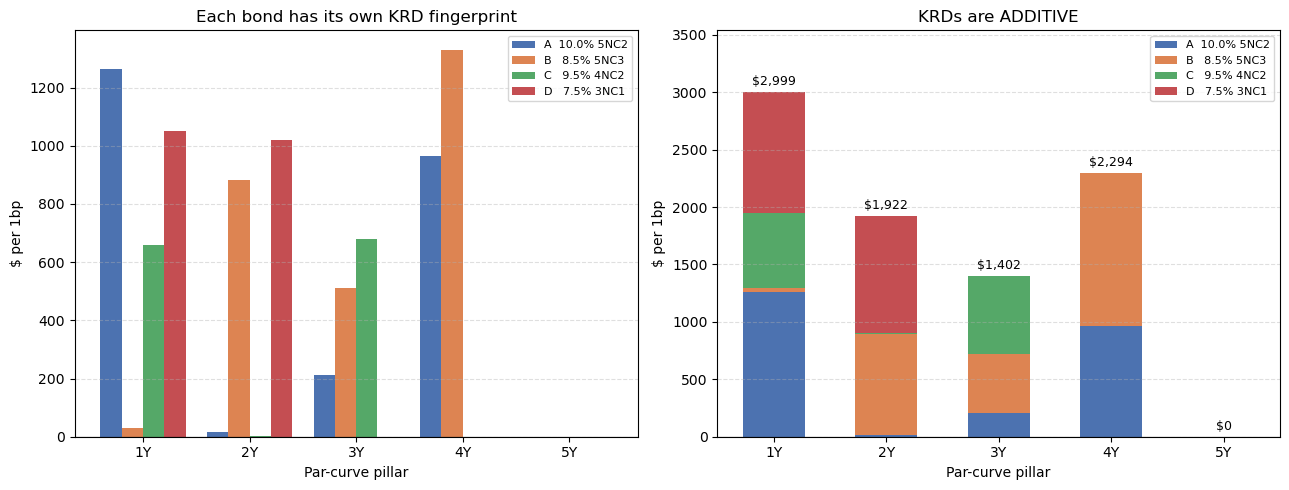

In [75]:
# the additivity picture
labels = []
for name, cpn, tenor, fc, spread, face in PORTFOLIO:
    labels.append(name.strip())
bond_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
x = np.arange(5)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# left: each bond on its own, every one a different shape
width = 0.2
for b in range(4):
    axL.bar(x + (b - 1.5) * width, book_krd[b], width,
            color=bond_colors[b], label=labels[b])
axL.axhline(0, color="black", linewidth=0.8)
axL.set_title("Each bond has its own KRD fingerprint")
axL.set_xlabel("Par-curve pillar")
axL.set_ylabel("$ per 1bp")
axL.set_xticks(x)
axL.set_xticklabels(["1Y", "2Y", "3Y", "4Y", "5Y"])
axL.legend(fontsize=8)
axL.grid(True, linestyle="--", alpha=0.4, axis="y")

# right: stack them, this is what the hedge actually sees
bottom = np.zeros(5)
for b in range(4):
    axR.bar(x, book_krd[b], 0.55, bottom=bottom,
            color=bond_colors[b], label=labels[b])
    for j in range(5):
        bottom[j] += book_krd[b][j]
axR.axhline(0, color="black", linewidth=0.8)
for j in range(5):
    axR.text(j, bottom[j] + 60, f"${bottom[j]:,.0f}", ha="center", fontsize=9)
axR.set_title("KRDs are ADDITIVE")
axR.set_xlabel("Par-curve pillar")
axR.set_ylabel("$ per 1bp")
axR.set_xticks(x)
axR.set_xticklabels(["1Y", "2Y", "3Y", "4Y", "5Y"])
axR.set_ylim(0, max(bottom) * 1.18)
axR.legend(fontsize=8)
axR.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

In [83]:
# build the portfolio strip on the aggregate KRD vector
port_strip = []
residual = list(agg_krd)
for pillar in [5, 4, 3, 2, 1]:
    if abs(residual[pillar - 1]) < 1:
        continue
    sp = price_swap(df, tenor=pillar, notional=1_000_000, verbose=False)
    unit_krd = swap_krd_vector(df, pillar, sp["par_rate"], 1_000_000)
    size = residual[pillar - 1] / unit_krd[pillar - 1] * 1_000_000
    port_strip.append((pillar, sp["par_rate"], size))
    for j in range(5):
        residual[j] -= unit_krd[j] * size / 1_000_000

print(f"  the portfolio hedge:")
for tenor, k, size in sorted(port_strip):
    print(f"    {tenor}Y pay-fixed @ {k*100:.4f}%   notional ${size:>12,.0f}")

krd_port_strip = [0.0] * 5
for tenor, k, size in port_strip:
    v = swap_krd_vector(df, tenor, k, size)
    for j in range(5):
        krd_port_strip[j] += v[j]

print()
print(f"  {'':<12} {'1Y':>8} {'2Y':>8} {'3Y':>8} {'4Y':>8} {'5Y':>8}")
print(f"  {'book KRD':<12} " + " ".join(f"{k:>8,.0f}" for k in agg_krd))
print(f"  {'strip KRD':<12} " + " ".join(f"{k:>8,.0f}" for k in krd_port_strip))
print(f"  {'residual':<12} " + " ".join(f"{agg_krd[j]-krd_port_strip[j]:>8,.0f}" for j in range(5)))

  the portfolio hedge:
    1Y pay-fixed @ 3.7500%   notional $  29,199,765
    2Y pay-fixed @ 3.8500%   notional $   9,540,303
    3Y pay-fixed @ 3.9800%   notional $   4,799,570
    4Y pay-fixed @ 4.1000%   notional $   6,473,868

                     1Y       2Y       3Y       4Y       5Y
  book KRD        2,999    1,922    1,402    2,294        0
  strip KRD       2,999    1,922    1,402    2,294        0
  residual            0        0        0        0        0


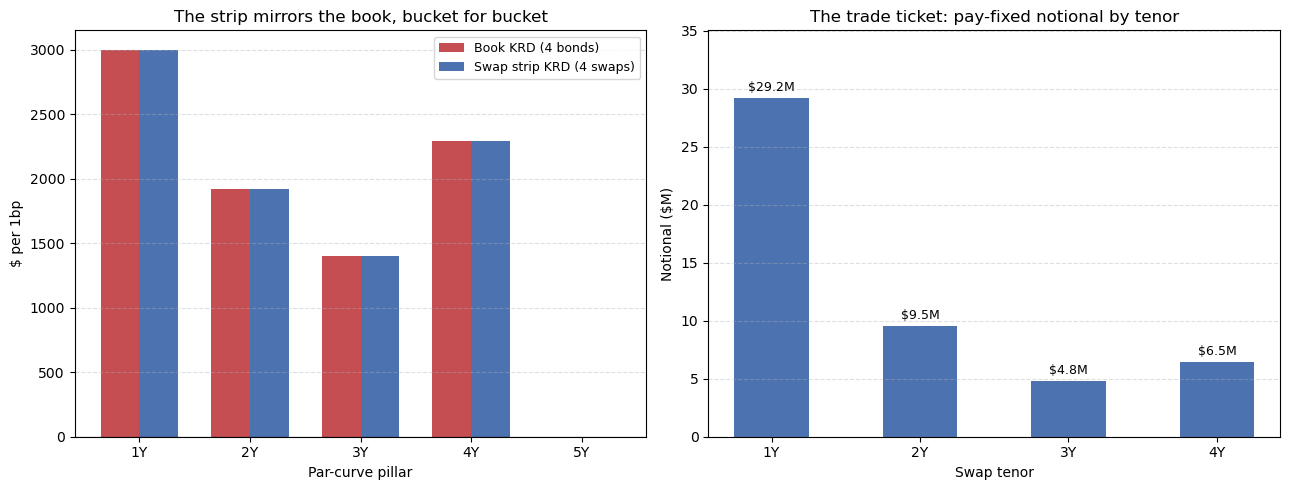

The strip mirrors the book bucket by bucket, leaving essentially no first-order rate risk. The largest ticket is the 1Y, which is where a book of callables concentrates its duration.


In [47]:
# the immunization, visually
resid_port = []
for j in range(5):
    resid_port.append(agg_krd[j] - krd_port_strip[j])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# left: book risk vs the swap strip that mirrors it
width = 0.35
axL.bar(x - width / 2, agg_krd, width, color="#C44E52", label="Book KRD (4 bonds)")
axL.bar(x + width / 2, krd_port_strip, width, color="#4C72B0",
        label=f"Swap strip KRD ({len(port_strip)} swaps)")
axL.axhline(0, color="black", linewidth=0.8)
axL.set_title("The strip mirrors the book, bucket for bucket")
axL.set_xlabel("Par-curve pillar")
axL.set_ylabel("$ per 1bp")
axL.set_xticks(x)
axL.set_xticklabels(["1Y", "2Y", "3Y", "4Y", "5Y"])
axL.legend(fontsize=9)
axL.grid(True, linestyle="--", alpha=0.4, axis="y")

# right: the actual trade ticket this analysis produces
strip_tenors = []
strip_sizes = []
for tenor, k, size in sorted(port_strip):
    strip_tenors.append(f"{tenor}Y")
    strip_sizes.append(size / 1e6)
axR.bar(strip_tenors, strip_sizes, 0.5, color="#4C72B0")
for i in range(len(strip_sizes)):
    axR.text(i, strip_sizes[i] + 0.6, f"${strip_sizes[i]:,.1f}M",
             ha="center", fontsize=9)
axR.set_title("The trade ticket: pay-fixed notional by tenor")
axR.set_xlabel("Swap tenor")
axR.set_ylabel("Notional ($M)")
axR.set_ylim(0, max(strip_sizes) * 1.2)
axR.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

print("The strip mirrors the book bucket by bucket, leaving essentially no first-order rate risk. The largest ticket is the 1Y, which is where a book of callables concentrates its duration.")

## 5. Value at risk

The 99% one day value at risk (VaR) is the loss that daily profit and loss exceeds 1% of the time. It is a percentile of a distribution.

We build that distribution by historical simulation: take a history of daily market moves, replay each one against today's book with a full revaluation, sort the results, and read the first percentile. Expected shortfall is the average loss beyond that point.

Two factors are simulated separately:

- Rate moves, a common level factor plus per pillar noise. The swap strip offsets these.
- Spread moves, around 8bp a day. No vanilla swap references an issuer's credit, so nothing offsets these.

The history is simulated rather than downloaded, so the notebook runs offline. Every VaR below is conditional on that calibration and is not an empirical estimate.


In [50]:
# the scenario history: 500 days of curve moves
rng = np.random.default_rng(42)
n_days = 500                                  # ~2 years of daily moves

# rate factor: common level move + small idiosyncratic noise per pillar
common = rng.normal(0, 0.00050, n_days)
rate_moves = {}
pillar_specs = [(1, 0.8, 0.00025), (2, 0.9, 0.00020), (3, 1.0, 0.00018),
                (4, 1.0, 0.00018), (5, 1.0, 0.00020)]
for pillar, beta, idio in pillar_specs:
    rate_moves[pillar] = beta * common + rng.normal(0, idio, n_days)

# spread factor: hits the bond only
spread_moves = rng.normal(0, 0.00080, n_days)

# what does one 'scenario' actually look like? here are the first five:
print("  the raw material, daily curve moves in basis points:")
print(f"  {'day':>4} {'1Y':>6} {'2Y':>6} {'3Y':>6} {'4Y':>6} {'5Y':>6} {'spread':>7}")
print("  " + "-" * 45)
for i in range(5):
    row = [rate_moves[p][i] * 10000 for p in range(1, 6)]
    print(f"  {i:>4} {row[0]:>+6.1f} {row[1]:>+6.1f} {row[2]:>+6.1f} {row[3]:>+6.1f} {row[4]:>+6.1f} {spread_moves[i]*10000:>+7.1f}")
print("  " + "-" * 45)
print(f"  ...and {n_days - 5} more. each row is one question: 'if this")
print("  happened tomorrow, what would today's book lose?'")

def var99(pnl):
    """99% VaR: the loss sitting at the 1st percentile of the P&L distribution."""
    return -np.percentile(pnl, 1)

def es99(pnl):
    """99% Expected Shortfall: the mean loss across the tail beyond the VaR."""
    v = var99(pnl)
    tail = pnl[pnl <= -v]
    return -tail.mean() if len(tail) > 0 else v

  the raw material, daily curve moves in basis points:
   day     1Y     2Y     3Y     4Y     5Y  spread
  ---------------------------------------------
     0   +4.6   +1.3   +0.5   +0.7   +2.6   +10.0
     1   -1.9   -6.1   -6.3   -6.4   -4.7    +5.5
     2   +1.2   +2.5   +6.1   +4.5   +5.8   +15.7
     3   +0.0   +5.5   +5.3   +5.2   +5.7   -12.4
     4  -15.2   -8.8  -10.1  -12.3   -7.3    -2.1
  ---------------------------------------------
  ...and 495 more. each row is one question: 'if this
  happened tomorrow, what would today's book lose?'


In [52]:
# portfolio VaR: full reval of the BONDS; swaps enter first-order
# (each bond gets a fresh tree per scenario; the swaps are linear instruments
#  so their P&L is KRD x move, accurate for daily-sized shocks, not for stress)
def run_portfolio_sim(use_rates, use_spread):
    """Daily P&L of the book, unhedged and hedged, with the chosen factors switched on."""
    pnl_u, pnl_h = [], []
    for i in range(n_days):
        bond_pnl = 0.0
        for b, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
            shifted = list(book_curves[b])
            for pillar in range(1, 6):
                if use_rates:
                    shifted[pillar] += rate_moves[pillar][i]
                if use_spread:
                    shifted[pillar] += spread_moves[i]
            if use_rates:
                shifted[0] += rate_moves[1][i]    # short end moves with 1Y
            if use_spread:
                shifted[0] += spread_moves[i]
            p_new = price_book_bond(cpn, tenor, fc, shifted)
            bond_pnl += (p_new - book_prices[b]) * face / 100

        sw = 0.0
        if use_rates:
            for pillar in range(1, 6):
                sw += krd_port_strip[pillar - 1] * (rate_moves[pillar][i] / bump)

        pnl_u.append(bond_pnl)
        pnl_h.append(bond_pnl + sw)
    return np.array(pnl_u), np.array(pnl_h)

port_total = run_portfolio_sim(True, True)
port_rate = run_portfolio_sim(True, False)
port_spread = run_portfolio_sim(False, True)

face_total = sum(b[5] for b in PORTFOLIO)
print(f"  99% daily VaR, ${face_total/1e6:.0f}M four-bond book, {n_days} scenarios")
print("  (bonds fully revalued on the lattice; swap P&L first-order via KRD)")
print("  " + "-" * 62)
print(f"  {'':<16} {'rate VaR':>11} {'spread VaR':>11} {'total VaR':>11} {'total ES':>11}")
for k, label in [(0, "unhedged"), (1, "strip-hedged")]:
    print(f"  {label:<16} ${var99(port_rate[k]):>10,.0f} ${var99(port_spread[k]):>10,.0f} ${var99(port_total[k]):>10,.0f} ${es99(port_total[k]):>10,.0f}")
print("  " + "-" * 62)

# where does that unhedged total VaR actually come from? read it by hand:
worst = np.sort(port_total[0])
print()
print("  the five worst days out of 500, unhedged book:")
for k in range(5):
    print(f"    #{k+1}:  ${worst[k]:>11,.0f}")
print(f"    #6:  ${worst[5]:>11,.0f}")
print("  1% of 500 days = 5 days, so the 99% VaR sits between #5 and #6:")
print(f"    99% VaR = ${var99(port_total[0]):,.0f}")
print(f"    99% ES = ${es99(port_total[0]):,.0f}   (mean of the tail beyond it)")
print()
red = (1 - var99(port_rate[1]) / var99(port_rate[0])) * 100
print(f"  rate-VaR reduction from the strip: {red:.0f}%")
print(f"  spread VaR untouched, that risk is the mandate, and no vanilla")
print(f"  swap references any of these issuers' credit.")

  99% daily VaR, $36M four-bond book, 500 scenarios
  (bonds fully revalued on the lattice; swap P&L first-order via KRD)
  --------------------------------------------------------------
                      rate VaR  spread VaR   total VaR    total ES
  unhedged         $    97,819 $   168,144 $   183,670 $   219,975
  strip-hedged     $     5,007 $   168,144 $   170,719 $   199,328
  --------------------------------------------------------------

  the five worst days out of 500, unhedged book:
    #1:  $   -266,933
    #2:  $   -226,136
    #3:  $   -216,654
    #4:  $   -197,444
    #5:  $   -192,706
    #6:  $   -183,579
  1% of 500 days = 5 days, so the 99% VaR sits between #5 and #6:
    99% VaR = $183,670
    99% ES = $219,975   (mean of the tail beyond it)

  rate-VaR reduction from the strip: 95%
  spread VaR untouched, that risk is the mandate, and no vanilla
  swap references any of these issuers' credit.


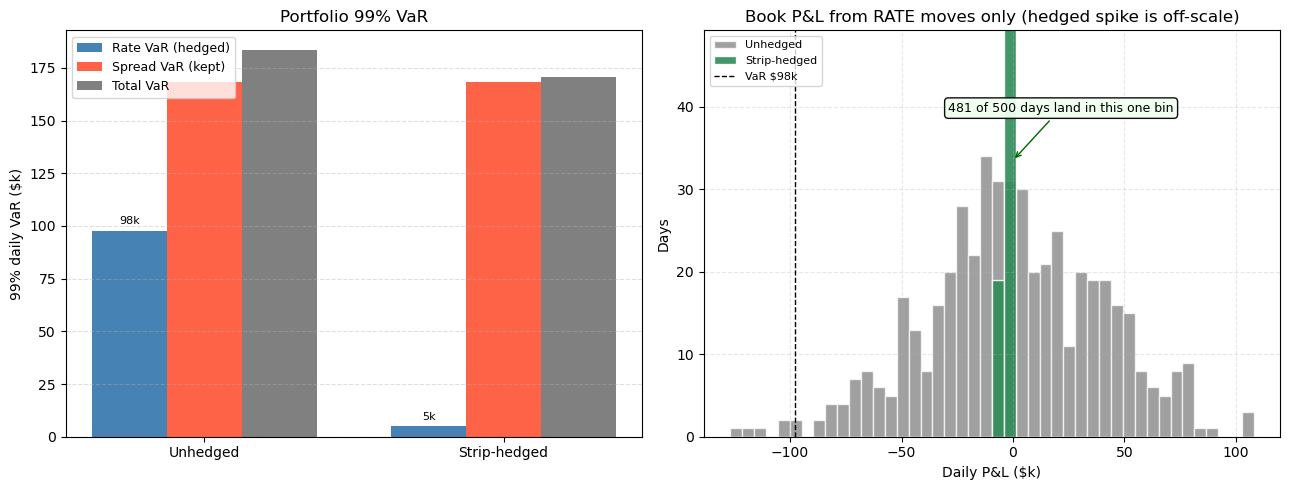

right: the unhedged book moves with the curve; after four swaps, rate moves barely register. this is DV01 immunization at portfolio level.


In [53]:
# portfolio VaR: the decomposition, then the distributions
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

# left: which bar the hedge actually moves
xv = np.arange(2)
width = 0.25
rate_v = [var99(port_rate[k])   / 1000 for k in range(2)]
spread_v = [var99(port_spread[k]) / 1000 for k in range(2)]
total_v = [var99(port_total[k])  / 1000 for k in range(2)]
axL.bar(xv - width, rate_v,   width, color="steelblue", label="Rate VaR (hedged)")
axL.bar(xv,         spread_v, width, color="tomato",    label="Spread VaR (kept)")
axL.bar(xv + width, total_v,  width, color="gray",      label="Total VaR")
for i in range(2):
    axL.text(i - width, rate_v[i] + 3, f"{rate_v[i]:,.0f}k", ha="center", fontsize=8)
axL.set_title("Portfolio 99% VaR")
axL.set_ylabel("99% daily VaR ($k)")
axL.set_xticks(xv)
axL.set_xticklabels(["Unhedged", "Strip-hedged"])
axL.legend(fontsize=9)
axL.grid(True, linestyle="--", alpha=0.4, axis="y")

# right: the rate-risk distribution before and after, on shared bins
edges = np.linspace(min(port_rate[0].min(), port_rate[1].min()) / 1000,
                    max(port_rate[0].max(), port_rate[1].max()) / 1000, 45)
cnt_u, _, _ = axR.hist(port_rate[0] / 1000, bins=edges, color="gray", alpha=0.75,
                       edgecolor="white", label="Unhedged")
cnt_h, _, _ = axR.hist(port_rate[1] / 1000, bins=edges, color="seagreen", alpha=0.9,
                       edgecolor="white", label="Strip-hedged")
axR.axvline(-var99(port_rate[0]) / 1000, color="black", linestyle="--",
            linewidth=1, label=f"VaR ${var99(port_rate[0])/1000:,.0f}k")
# the hedged spike is several times taller than the unhedged bell: clip the
# axis to the bell and label the spike instead of squashing everything flat
top = max(cnt_u) * 1.45
axR.set_ylim(0, top)
spike_note = f"{int(max(cnt_h))} of {n_days} days land in this one bin"
axR.annotate(spike_note,
             xy=(0, top * 0.68), xytext=(0.62, 0.80), textcoords="axes fraction",
             fontsize=9, ha="center",
             arrowprops=dict(arrowstyle="->", color="darkgreen"),
             bbox=dict(boxstyle="round", facecolor="honeydew", alpha=0.95))
axR.set_title("Book P&L from RATE moves only (hedged spike is off-scale)")
axR.set_xlabel("Daily P&L ($k)")
axR.set_ylabel("Days")
axR.legend(fontsize=8, loc="upper left")
axR.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

print("right: the unhedged book moves with the curve; after four swaps, rate moves barely register. this is DV01 immunization at portfolio level.")

Rate VaR falls by 95%. Spread VaR is identical on both books.

Total VaR barely moves. Two roughly independent risks combine close to quadrature, so removing the rate leg drops the total to the spread floor and no further. A hedge that took total VaR to zero would mean the mandate had been hedged away.


In [55]:
# backtest the hedged book's VaR: count exceptions, Basel traffic-light style
hedged = port_total[1]
v = var99(hedged)
last_250 = hedged[-250:]

exceptions = 0
for pnl in last_250:
    if pnl < -v:            # an 'exception': the day lost more than VaR predicted
        exceptions += 1

if exceptions <= 4:
    zone = "GREEN"
elif exceptions <= 9:
    zone = "YELLOW"
else:
    zone = "RED"

print(f"  strip-hedged book, last 250 days: {exceptions} exception(s) vs 99% VaR")
print(f"  expected at 99% confidence      : ~2.5")
print(f"  Basel traffic-light zone        : {zone}  (green 0-4, yellow 5-9, red 10+)")
print()
print("  caveat: this is an in-sample backtest; production VaR would be tested on a rolling out-of-sample window.")

  strip-hedged book, last 250 days: 2 exception(s) vs 99% VaR
  expected at 99% confidence      : ~2.5
  Basel traffic-light zone        : GREEN  (green 0-4, yellow 5-9, red 10+)

  caveat: this is an in-sample backtest; production VaR would be tested on a rolling out-of-sample window.


That is an illustration of the mechanics, not a validation of the model. The VaR is computed on the same synthetic sample it is tested against, so consistency is close to guaranteed. A real backtest uses a rolling out of sample window.

---
## 6. Hedge decay and the cost of rebalancing

The hedge we built is static. It’s sized precisely for the book’s interest rate risk as of today. But callable bonds change their behavior over time, while the swap strip stays locked in place.

Two things knock the hedge out of alignment:

- Interest rates move. If rates fall, the embedded calls go further in the money, so the bonds act shorter and their duration shrinks. The static strip stays sized for the old, longer duration, so it over-hedges.
- Credit spreads move. If spreads widen, the calls drift out of the money. The bonds stop behaving like short-term paper and start acting like longer maturity bullets—their duration grows. The static strip stays sized for the old, shorter duration, so it under-hedges.
In both cases, the hedge is now mismatched against a book that no longer looks like it did when the trade was put on. To stay effective, the strip must be re-solved periodically. Let’s measure what that rebalancing actually costs.


   spread drift   book DV01  strip DV01   mismatch
  ------------------------------------------------
            0bp $     8,606 $     8,617 $      -11
           25bp $     8,865 $     8,617 $      248
           50bp $     8,774 $     8,617 $      157
          100bp $     9,273 $     8,617 $      656
          150bp $     9,519 $     8,617 $      902
          200bp $    10,075 $     8,617 $    1,458
          300bp $    10,128 $     8,617 $    1,511
  ------------------------------------------------


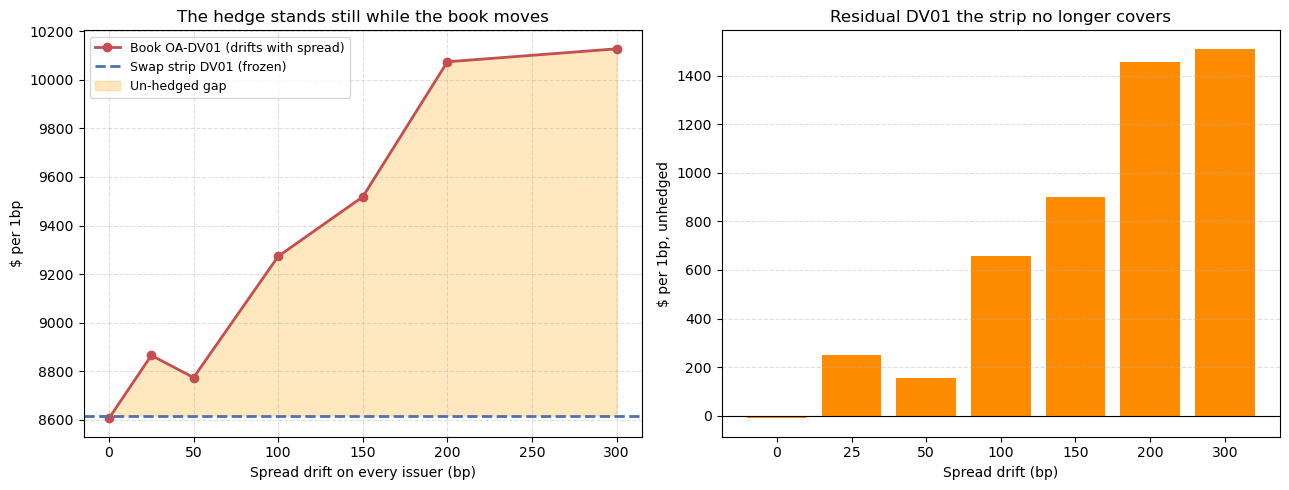

  rates did not move, but wider spreads made the callables longer and increased their DV01.
  the swap strip stayed unchanged, so the book is no longer fully hedged and must be rebalanced.


In [60]:
# and the gamma is still there: the book's DV01 drifts, the strip does not
# widen every issuer's spread, rebalance NOTHING, watch the gap open
drifts = [0, 25, 50, 100, 150, 200, 300]
book_dv01_path = []
for d in drifts:
    agg = 0.0
    for b, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
        drifted = [r + d / 10000.0 for r in book_curves[b]]
        up = [r + bump for r in drifted]
        dn = [r - bump for r in drifted]
        agg += (price_book_bond(cpn, tenor, fc, dn) - price_book_bond(cpn, tenor, fc, up)) / 2 * face / 100
    book_dv01_path.append(agg)

strip_dv01 = sum(krd_port_strip)

print(f"  {'spread drift':>13} {'book DV01':>11} {'strip DV01':>11} {'mismatch':>10}")
print("  " + "-" * 48)
for i in range(len(drifts)):
    print(f"  {drifts[i]:>11}bp ${book_dv01_path[i]:>10,.0f} ${strip_dv01:>10,.0f} ${book_dv01_path[i] - strip_dv01:>9,.0f}")
print("  " + "-" * 48)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

axL.plot(drifts, book_dv01_path, "o-", color="#C44E52", linewidth=2,
         label="Book OA-DV01 (drifts with spread)")
axL.axhline(strip_dv01, color="#4C72B0", linewidth=2, linestyle="--",
            label="Swap strip DV01 (frozen)")
axL.fill_between(drifts, book_dv01_path, strip_dv01, color="orange", alpha=0.25,
                 label="Un-hedged gap")
axL.set_title("The hedge stands still while the book moves")
axL.set_xlabel("Spread drift on every issuer (bp)")
axL.set_ylabel("$ per 1bp")
axL.legend(fontsize=9)
axL.grid(True, linestyle="--", alpha=0.4)

mismatch = []
for i in range(len(drifts)):
    mismatch.append(book_dv01_path[i] - strip_dv01)
axR.bar([str(d) for d in drifts], mismatch, color="darkorange")
axR.axhline(0, color="black", linewidth=0.8)
axR.set_title("Residual DV01 the strip no longer covers")
axR.set_xlabel("Spread drift (bp)")
axR.set_ylabel("$ per 1bp, unhedged")
axR.grid(True, linestyle="--", alpha=0.4, axis="y")

plt.tight_layout()
plt.show()

print("  rates did not move, but wider spreads made the callables longer and increased their DV01.")
print("  the swap strip stayed unchanged, so the book is no longer fully hedged and must be rebalanced.")

The hedge has to be re-solved periodically. What does that cost?

Each rebalance trades the change in notional at each tenor. Crossing the bid/ask on a vanilla swap costs roughly a quarter of a basis point on the fixed rate, which in present value terms is notional times annuity times half spread.

We will assume that spreads widen 25bp a quarter over one year, the strip is re-solved each quarter, and every adjustment is costed.


In [63]:
HALF_SPREAD_BP = 0.25       # bid/ask on a standard vanilla swap tenor, in bp

def solve_strip(target_krd):
    """Re-solve the immunizing strip against a given book KRD vector."""
    strip = []
    residual = list(target_krd)
    for pillar in [5, 4, 3, 2, 1]:
        if abs(residual[pillar - 1]) < 1:
            continue
        sp = price_swap(df, tenor=pillar, notional=1_000_000)
        unit = swap_krd_vector(df, pillar, sp["par_rate"], 1_000_000)
        size = residual[pillar - 1] / unit[pillar - 1] * 1_000_000
        strip.append((pillar, sp["par_rate"], size))
        for j in range(5):
            residual[j] -= unit[j] * size / 1_000_000
    return strip

def book_krd_at(drift):
    """Aggregate book KRD after every issuer spread widens by `drift`."""
    agg = [0.0] * 5
    for b, (name, cpn, tenor, fc, spread, face) in enumerate(PORTFOLIO):
        curve = [r + drift for r in book_curves[b]]
        kv = krd_vector_book(cpn, tenor, fc, curve, face)
        for j in range(5):
            agg[j] += kv[j]
    return agg

# annuity per $1 of notional, one per tenor, for costing the trades
annuity = {}
for t in [1, 2, 3, 4, 5]:
    annuity[t] = price_swap(df, tenor=t, notional=1)["annuity"]

current = {}
for tenor, k, size in port_strip:
    current[tenor] = size

print("  quarterly rebalancing, spreads widening 25bp per quarter")
print("  " + "-" * 62)
print(f"  {'quarter':>8} {'spread':>8} {'notional traded':>17} {'cost':>10}")
print("  " + "-" * 62)

total_cost = 0.0
for q, drift in enumerate([0.0025, 0.0050, 0.0075, 0.0100], start=1):
    new_strip = solve_strip(book_krd_at(drift))
    new = {}
    for tenor, k, size in new_strip:
        new[tenor] = size

    traded = 0.0
    cost = 0.0
    for tenor in [1, 2, 3, 4, 5]:
        delta = abs(new.get(tenor, 0.0) - current.get(tenor, 0.0))
        traded += delta
        cost += delta * annuity[tenor] * HALF_SPREAD_BP * 1e-4
    total_cost += cost
    current = new
    print(f"  {q:>8} {drift*10000:>6.0f}bp ${traded:>16,.0f} ${cost:>9,.0f}")

print("  " + "-" * 62)
print(f"  {'YEAR':>8} {'':>8} {'':>17} ${total_cost:>9,.0f}")
print()
print(f"  annual rebalancing cost : ${total_cost:,.0f}")
print(f"  as bp of book market value ({total_mv/1e6:.1f}M): {total_cost / total_mv * 10000:.1f}bp per year")
print(f"  versus the rate VaR it protects: ${var99(port_rate[0]):,.0f} per day unhedged")

  quarterly rebalancing, spreads widening 25bp per quarter
  --------------------------------------------------------------
   quarter   spread   notional traded       cost
  --------------------------------------------------------------
         1     25bp $       8,075,794 $      308
         2     50bp $         477,953 $       22
         3     75bp $         471,430 $       22
         4    100bp $      14,880,450 $      597
  --------------------------------------------------------------
      YEAR                            $      949

  annual rebalancing cost : $949
  as bp of book market value (36.7M): 0.3bp per year
  versus the rate VaR it protects: $97,819 per day unhedged


  versus the rate VaR it protects: $97,819 per day unhedged


The alternative is a Bermudan swaption per bond. That hedges the option exactly and needs no rebalancing, but charges a premium up front, quotes a wide bid/ask, and is thinly/not traded in EM sizes.

Two things this understates: it costs only the spread drift, not the rate driven gamma, and it assumes a rebalance is always executable at a quarter of a basis point, which will not hold in a stressed market.


---
## 7. Limitations

Every item below is a deliberate simplification.

**Constant volatility.** The lattice uses one volatility, 15%, at every rate level and forever. Real rate volatility has a term structure and a smile, and desks calibrate to the swaption surface. Section 1 showed the price moving more than half a point per five volatility points, so the most price sensitive input in the model is the one that is assumed.

**One factor in the tree.** The tree models the short rate only, although the whole point is that the problem has two factors. Spread enters as an outside shift, which captures levels but not dynamics: no mean reversion, no rate and spread correlation inside the tree, and the exercise boundary never sees spread uncertainty, only spread levels.

**Credit is a spread, never a default.** Each issuer curve is the SOFR curve plus a flat spread, so credit is a shifted interest rate curve and nothing more. There is no hazard rate, no default probability, no recovery assumption, no survival probability and no CDS curve. What is computed is spread VaR, meaning mark to market repricing risk, and never credit VaR. Real credit loss is skewed and fat tailed in a way a Gaussian spread shock cannot reach, so this is a floor on the true risk rather than a measure of it.

**Annual time steps.** Real Bermudans are usually callable quarterly or continuously after the first call date. Annual steps make the exercise boundary coarse and push the final cash flow's risk onto the 4Y pillar.

**Constant OAS bumping.** Effective duration holds the option adjusted spread fixed while the curve moves. Spreads and rates tend to move together, so this overstates measured duration slightly.

**A frictionless call rule.** Taking the minimum of call price and present value assumes the issuer refinances the moment it is economic. Real issuers face fees, market access and signalling, and call later than the model says.

**Linearized swap profit and loss.** The bonds are fully revalued in every VaR scenario, but the swaps enter through their KRD. That is fine for daily moves and understates error in large stress moves.

**A synthetic VaR history.** The factors are Gaussian and chosen, not estimated from market data, and the backtest is in sample. Transaction costs are ignored except in section 6.

None of this changes the conclusion. The two factor structure of the residual is a property of the instrument, not of the model. The magnitudes would move.


---
## Conclusion

99% daily VaR on the $36M four bond book:

| Book | Rate VaR | Spread VaR | Total VaR |
|---|---|---|---|
| Unhedged | \$97.8k | \$168.1k | \$183.7k |
| Immunized with 4 vanilla swaps | **\$5.0k** | \$168.1k | \$170.7k |

Four trades remove 95% of the book's interest rate risk and leave the credit risk untouched.

**1. A callable is a bond plus a short option, and the option ignores the hedge.** The EM 5NC2 has an option adjusted DV01 of USD 2,452 against USD 4,145 for the same bond without the call, so 59% of a bullet's rate risk. That ratio depends on where rates and spreads are.

**2. Key rate durations aggregate, so the hedge scales.** Four callables with four call schedules put their risk in four places on the curve. Summing the reports gives one row that four swaps cancel exactly.

**3. The residual is structural.** Two factors drive one exercise decision and a swap sees one of them. Widen every spread by 300bp with no rate moving and the book's DV01 walks away from a frozen strip, with no profit or loss on the day to warn you. Either rebalance, at a few basis points of market value a year, or buy the optionality back and pay the premium up front.
